# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 2

Do wykonania zadań proszę zapoznać się z metodami, właściwościami, oraz funkcjami:
`__repr__`, `__str__`, `__add__`, `__sub__`, `__eq__`, `__lt__`, `__gt__`, `__le__`, `__ge__`, `__ne__`, `__hash__`, `__truediv__`, `__mul__`, `__class__`, `__name__`, `id`.

Operatory: https://docs.python.org/3/library/operator.html


**UWAGA**: W niniejszym laboratorium proszę nie korzystać z zewnętrzych modułów/bibliotek (poza biblioteką _matplotlib_).

**UWAGA 2**: Obsługę błędów należy zrealizować w postaci wyjątków.

### Zadanie 1

Napisz klasę `Vector` udostępniającą funkcjonalność:
- reprezentuje wektor dowolnej długości,
- obiekt inicjowany listą (np. `Vector([1, 2, 3])`,
- posiada funkcję zwracającą moduł wektora,
- umożliwia dodawanie (`+`) i odejmowanie (`-`) wektorów. Dodaj obsługę błędów (różna długość (liczba elementów) wektora),
- możliwość wyświetlenia wektora jako listy za pomocą funkcji `print(v)` (metoda `__str__`),
- uruchomienie komórki zawierającej jedynie nazwę zmiennej (typu `Vector`) spowoduje wyświetlenie nazwy typu `Vector`, adresu zmiennej w pamięci (funkcja `id`) oraz jej zawartości, np. `<Vector([1, 2, 3]) at 140185630442880>` (metoda `__repr__`)

In [2]:
import matplotlib.pyplot as plt

In [7]:
class Vector:
    def __init__(self, components):
        self.components = tuple(components)
        
    def __repr__(self):
        return f"{self.__class__.__name__} {list(self.components)} at {id(self)}"
        
    def __str__(self):
        # return str(self.components)
        return f"{list(self.components)}"
    
    def __len__(self):
        return len(self.components)
        
    def magnitude(self):
        return sum([c**2 for c in self.components])**(1/2)
    
    def _check_compatible(self, other):
        if not isinstance(other, Vector):
            raise TypeError(f"Unsupported operand type: {type(other).__name__}")
        if len(self) != len(other):
            raise ValueError(f"Cannot operate on vectors of different lengths: {len(self)} and {len(other)}")
        return True
        
    def __add__(self, other):
        self._check_compatible(other)
        return Vector([a + b for a, b in zip(self.components, other.components)])
        
    def __sub__(self, other):
        self._check_compatible(other)
        return Vector([a - b for a, b in zip(self.components, other.components)])
        
    def __eq__(self, other):
        self._check_compatible(other)
        return Vector([a==b for a,b in zip(self.components, other.components)])

    def __ne__(self, other):
        self._check_compatible(other)
        return Vector([a!=b for a,b in zip(self.components, other.components)])
        
    def __le__(self, other):
        self._check_compatible(other)
        return Vector([a<=b for a,b in zip(self.components, other.components)])
        
    def __lt__(self, other):
        self._check_compatible(other)
        return Vector([a<b for a,b in zip(self.components, other.components)])

    def __gt__(self, other):
        self._check_compatible(other)
        return Vector([a>b for a,b in zip(self.components, other.components)])
        
    def __ge__(self, other):
        self._check_compatible(other)
        return Vector([a>=b for a,b in zip(self.components, other.components)])

    def __mul__(self, scalar):
        if not isinstance(scalar, (int,float)):
            raise TypeError("Wrong scalar type")
        return Vector([a*scalar for a in self.components])

    def __truediv__(self, scalar):
        if not isinstance(scalar, (int,float)):
            raise TypeError("Wrong scalar type")
        if scalar == 0:
            raise ZeroDivisionError("Cannot divide by 0")
        return Vector([a/scalar for a in self.components])
        
    def plot(self):
        if len(self.components) != 2:
            print("Vector must be two-dimensional to plot.")
            return
        plt.figure()
        plt.quiver(0, 0, self.components[0], self.components[1], angles='xy', scale_units='xy', scale=1)
        plt.xlim(-abs(self.components[0]) - 1, abs(self.components[0]) + 1)
        plt.ylim(-abs(self.components[1]) - 1, abs(self.components[1]) + 1)
        plt.axhline(0, color='black', linewidth=0.5)
        plt.axvline(0, color='black', linewidth=0.5)
        plt.grid()
        plt.show()
        
    def __hash__(self):
        return hash(self.components)
        

v = Vector([1,2,3])
v2 = Vector([4,5,6])
v


Vector [1, 2, 3] at 1531174180752

In [8]:
print(v)

[1, 2, 3]


In [9]:
v.magnitude()

3.7416573867739413

In [11]:
v3 = v+v2
v3

Vector [5, 7, 9] at 1531174690256

In [12]:
v3 = v-v2
v3

Vector [-3, -3, -3] at 1531174306320

In [13]:
v4 = v + [1,3,4]
v4

TypeError: Unsupported operand type: list

### Zadanie 2

Do wcześniej zaimplementowanej klasy dopisz funkcje pozwalające na porównanie wektorów za pomocą operatorów: `==`, `>=`, `<=`, `>`, `<`, `!=`. Porównanie ma zostać wykonane na poziomie elementów wektorów (_element wise_), poniżej przykład:

```ipython
 In [1]: a = Vector([1, 2, 3]) \
    ...: b = Vector([3, 2, 1]) \
    ...: a <= b
Out [1]: <Vector([True, True, False]) at 140185575662832>
```

In [14]:
a = Vector([1, 2, 3]) 
b = Vector([3, 2, 1])
vEq = a <= b
vEq

Vector [True, True, False] at 1531181227920

In [15]:
vGt = a > b
vGt

Vector [False, False, True] at 1531174344080

In [16]:
vNe = a != b
vNe

Vector [True, False, True] at 1531174306768

### Zadanie 3

Napisz funkcję umożliwiającą wyświetlenie wektora (`Vector`) zaczepionego w punkcie (0,0) na wykresie (zaimplementuj wyświetlanie za pomocą biblioteki `matplotlib`. 

> **UWAGA**: Funkcja powinna działać tylko dla wektora o dwóch wymiarach (dwuelementowa lista) - wykres 2D i wyświetlać komunikat jeżeli wymiar jest inny.

> Podpowiedź: możesz wykorzystać funkcję [matplotlib.pyplot.arrow](https://matplotlib.org/3.5.1/api/_as_gen/matplotlib.pyplot.arrow.html)

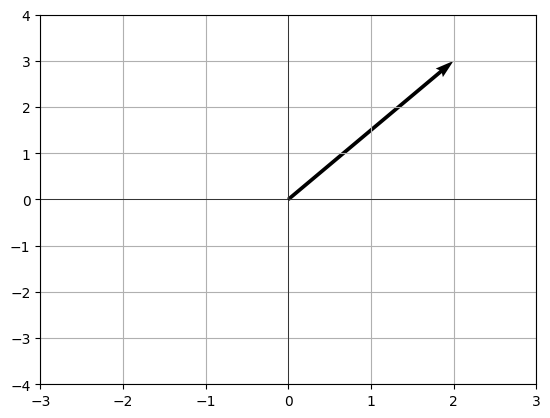

In [17]:
vplt = Vector([2,3])
vplt.plot()

### Zadanie 4

Dodaj możliwość zastosowania obiektu klasy `Vector` jako klucza w słowniku. Np.:

```python
d = {
    Vector([1, 2, 3]): 'Wektor 1',
    Vector([2, 2, 3]): 'Wektor 2'
}
d[Vector([2, 2, 3])]
```

In [18]:
d = {
    Vector([1, 2, 3]): 'Wektor 1',
    Vector([2, 2, 3]): 'Wektor 2'
}
d[Vector([2, 2, 3])]

'Wektor 2'

### Zadanie 5

Dodaj funkcjonalność:
- dzielenia przez skalar (np. `Vector([2, 4]) / 2`),
- mnożenia przez skalar (np. `Vector([2, 4]) * 2`).

> Podpowiedź: Pamiętaj o obsłudze błędów.

In [19]:
vMul = Vector([2, 4]) * 2
vMul

Vector [4, 8] at 1531182563152

In [20]:
Vector([2, 4]) * "2"

TypeError: Wrong scalar type

In [21]:
vDiv = Vector([2, 4]) / 2
vDiv

Vector [1.0, 2.0] at 1531175169808

In [22]:
Vector([2, 4]) / 0

ZeroDivisionError: Cannot divide by 0